In [3]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import reco

### Tools 

In [12]:
def Delta_ht(list):
    """ crea un array con la differenza di tempo tra 2 Hit consecutivi"""
    delta=np.empty(0)
    for i in range(1, len(list)):
        term= (list[i] - list[i-1])
        delta= np.append(delta, term)
    return delta

def dati_to_events(datas):
    """ produce un array di reco.Hit dagli hit registrati nei file"""
    hits=np.empty(0)
    for i in range(1, datas.shape[0]):
        m=int(datas['mod_id'][i])
        d=int(datas['det_id'][i])
        h=int(datas['hit_time'][i])
        term= reco.Hit(m,d,h)
        hits=np.append(hits,term)
    return hits

def all_reco(a1, a2): 
    """ ordina temporalmente 2 array di reco.Hit
        NOTA: 'a1' e 'a2' sono già ordinati temporalmente. """
    delta= np.empty(0)
    s=0
    z=0
    while(s < len(a1) and z < len(a2)):
        min=a1[s]
        if (a1[s] < a2[z]):
            min=a2[z]
            z=z+1
        else: s=s+1
        delta=np.append(delta, min)
    if(s < len(a1)):
        for i in range(s, len(a1)):
            delta= np.append(delta, a1[i])
    elif(z < len(a1)):
        for i in range(z, len(a2)):
            delta= np.append(delta, a2[i])
    return delta

### Dati fittizi di alcune hits registrate da un rivelatore di neutrini del **KM3NeT** 

I file rappresentano i dati relativi a un (fittizio) rivelatore con sensori per fotoni Cerenkov su 1 secondo di acquisizione dati.
Il rivelatore è organizzato in 4 moduli, ognuno contenenete 5 sensori.

In [5]:
M0_hits=pd.read_csv('/home/nicola_polito/MCF/dati/dati-e5/hit_times_M0.csv', sep=";")
M1_hits=pd.read_csv('/home/nicola_polito/MCF/dati/dati-e5/hit_times_M1.csv', sep=";")
M2_hits=pd.read_csv('/home/nicola_polito/MCF/dati/dati-e5/hit_times_M2.csv', sep=";")
M3_hits=pd.read_csv('/home/nicola_polito/MCF/dati/dati-e5/hit_times_M3.csv', sep=";")


print(M0_hits.head())
print(M0_hits.columns)

   mod_id  det_id  hit_time
0       0       3    287827
1       0       0    440181
2       0       3    440192
3       0       4    440208
4       0       3    605229
Index(['mod_id', 'det_id', 'hit_time'], dtype='object')


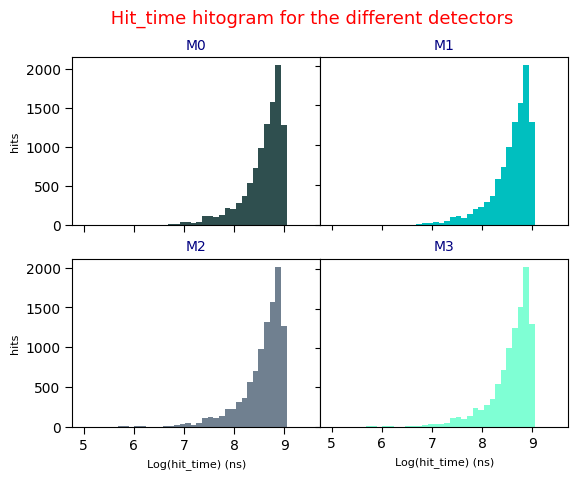

In [6]:
# Hist Hit-Time
fig1 = plt.figure()
gs = fig1.add_gridspec(2,2, hspace=0.2, wspace=0)
(ax1,ax2), (ax3, ax4) = gs.subplots(sharex=True)
plt.suptitle(' Hit_time hitogram for the different detectors ', fontsize=13, color = 'red')

#M0
M0_log_hits= np.log10(M0_hits['hit_time'])
n, bis, p = ax1.hist(M0_log_hits, bins=40, range=(5,9.5), color='darkslategray')
ax1.set_title('M0', color='navy', fontsize=10)
ax1.set_ylabel('hits', fontsize=8)
ax1.set_xlabel('Log(hit_time) (ns)', fontsize=8)
ax1.tick_params(axis='x', size=5)
ax1.tick_params(axis='y',size=5)

#M1
M1_log_hits= np.log10(M1_hits['hit_time'])
n, bis, p = ax2.hist(M1_log_hits, bins=40, range=(5,9.5), color='c')
ax2.set_title('M1', color='navy', fontsize=10)
ax2.set_ylabel('hits', fontsize=8)
ax2.set_xlabel('Log(hit_time) (ns)', fontsize=8)

#M2
M2_log_hits= np.log10(M2_hits['hit_time'])
n, bis, p = ax3.hist(M2_log_hits, bins=40, range=(5,9.5), color='slategray')
ax3.set_title('M2', color='navy', fontsize=10)
ax3.set_ylabel('hits', fontsize=8)
ax3.set_xlabel('Log(hit_time) (ns)', fontsize=8)
ax3.tick_params(axis='x', size=5)
ax3.tick_params(axis='y',size=5)

#M3
M3_log_hits= np.log10(M3_hits['hit_time'])
n, bis, p = ax4.hist(M3_log_hits, bins=40, range=(5,9.5), color='aquamarine')
ax4.set_title('M3', color='navy', fontsize=10)
ax4.set_ylabel('hits', fontsize=8)
ax4.set_xlabel('Log(hit_time) (ns)', fontsize=8)

for ax in fig1.get_axes():
    ax.label_outer()

Istogramma delle differenze dei tempi  $ \Delta T $ fra Hit consecutivi, per ciascuno dei moduli del rivelatore

/tmp/ipykernel_14773/4118262687.py:9: RuntimeWarning: divide by zero encountered in log10
  dM0_log_hits=np.log10(delta_M0)
/tmp/ipykernel_14773/4118262687.py:19: RuntimeWarning: divide by zero encountered in log10
  dM1_log_hits=np.log10(delta_M1)
/tmp/ipykernel_14773/4118262687.py:20: RuntimeWarning: divide by zero encountered in log10
  dM1_log_hits=np.log10(Delta_ht(M1_hits['hit_time']))
/tmp/ipykernel_14773/4118262687.py:28: RuntimeWarning: divide by zero encountered in log10
  dM2_log_hits=np.log10(delta_M2)
/tmp/ipykernel_14773/4118262687.py:29: RuntimeWarning: divide by zero encountered in log10
  dM2_log_hits=np.log10(Delta_ht(M2_hits['hit_time']))
/tmp/ipykernel_14773/4118262687.py:39: RuntimeWarning: divide by zero encountered in log10
  dM3_log_hits=np.log10(delta_M3)
/tmp/ipykernel_14773/4118262687.py:40: RuntimeWarning: divide by zero encountered in log10
  dM3_log_hits=np.log10(Delta_ht(M3_hits['hit_time']))


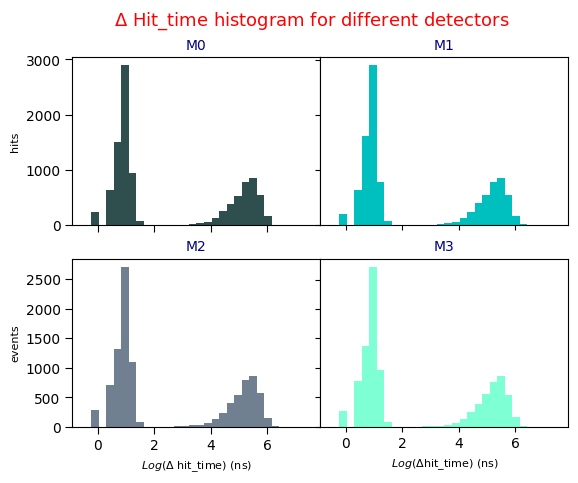

In [ ]:
#Hist Delta Hit Time
fig2 = plt.figure()
gs = fig2.add_gridspec(2,2, hspace=0.2, wspace=0)
(ax1,ax2), (ax3, ax4) = gs.subplots()
plt.suptitle(r'$\Delta$ Hit_time histogram for different detectors ', fontsize=13, color = 'red')

#M0
delta_M0=Delta_ht(M0_hits['hit_time'])
dM0_log_hits=np.log10(delta_M0)
n, bis, p = ax1.hist(dM0_log_hits, bins=30, range=(-0.5, 7.5), color='darkslategray')
ax1.set_title('M0', color='navy', fontsize=10)
ax1.set_ylabel('hits', fontsize=8)
ax1.set_xlabel(r'$Log(\Delta$ hit_time) (ns)', fontsize=8)
ax1.tick_params(axis='x', size=5)
ax1.tick_params(axis='y',size=5)

#M1
delta_M1=Delta_ht(M1_hits['hit_time'])
dM1_log_hits=np.log10(delta_M1)
dM1_log_hits=np.log10(Delta_ht(M1_hits['hit_time']))
n, bis, p = ax2.hist(dM1_log_hits, bins=30, range=(-0.5, 7.5), color='c')
ax2.set_title('M1', color='navy', fontsize=10)
ax2.set_ylabel('hits', fontsize=8)
ax2.set_xlabel(r'$Log(\Delta$ hit_time) (ns)', fontsize=8)

#M2
delta_M2=Delta_ht(M2_hits['hit_time'])
dM2_log_hits=np.log10(delta_M2)
dM2_log_hits=np.log10(Delta_ht(M2_hits['hit_time']))
n, bis, p = ax3.hist(dM2_log_hits, bins=30, range=(-0.5, 7.5), color='slategray')
ax3.set_title('M2', color='navy', fontsize=10)
ax3.set_ylabel('events', fontsize=8)
ax3.set_xlabel('$Log(\Delta$ hit_time) (ns)', fontsize=8)
ax3.tick_params(axis='x', size=5)
ax3.tick_params(axis='y',size=5)

#M3
delta_M3=Delta_ht(M3_hits['hit_time'])
dM3_log_hits=np.log10(delta_M3)
dM3_log_hits=np.log10(Delta_ht(M3_hits['hit_time']))
n, bis, p = ax4.hist(dM3_log_hits, bins=30, range=(-0.5, 7.5), color='aquamarine')
ax4.set_title('M3', color='navy', fontsize=10)
ax4.set_ylabel('events', fontsize=8)
ax4.set_xlabel('$Log(\Delta $hit_time) (ns)', fontsize=8)

for ax in fig2.get_axes():
    ax.label_outer()

**INTERPRETAZIONE DEI GRAFICI:**

Gli istogrammi degli hit times per i 4 differenti moduli mostrano che ci sono molti eventi di hit verso la fine dell'acquisizione (in particolare intorno ai 0.7 s) e pochi all'inizio della stessa e ciò è vero per tutti e 4 i moduli.

Gli istogrammi della differenza tra due hit time successivi mostrano che la maggior parte degli eventi hanno un delta_hit molto piccolo (eventi molto vicini tra di loro), mentre tutti gli altri presentano una differenza temporale più significativa.
 
In particolare, quasi nessun evento ha una distanza temporale dal successivo compresa tra 40 e 5600 ns 
e, poichè gli hit appartenenti ad uno stesso evento saranno presumibilmente raggruppati nel tempo, mentre hit relativi ad eventi diversi avranno una separazione temporale maggiore, ciò distingue tra un evento di interesse e un evento di non interesse.

Complessivamente si può evincere che si hanno eventi di interesse verso la fine dell'acquisizione registrati da tutti e 4 i moduli.

### Definizione della Classe **HIT**

Contenuta nel modulo '*reco.py*'

### Gestione di tutti gli Hits rivelati

Creo degli oggetti di tipo *reco.Hit* dai dati e ordino temporalmente tutti gli Hits rivelati da tutti i moduli

In [14]:
print(type(M0_hits))

array_M0_hits= dati_to_events(M0_hits) 
array_M1_hits= dati_to_events(M1_hits)
array_M2_hits= dati_to_events(M2_hits)
array_M3_hits= dati_to_events(M3_hits)

print(type(array_M0_hits[3])) #array di reco.Hit
print(type(array_M0_hits[3].id_module)) #ora sono int

print('\n')
print(array_M0_hits[0], '\n')

#all_reco.Hit
arr1=all_reco(array_M0_hits, array_M1_hits)
print(len(arr1)) # dovrebbe essere 20384
arr2=all_reco(arr1, array_M2_hits)
print(len(arr2)) # dovrebbe essere 30577
all_ord_hits=all_reco(arr2, array_M3_hits)
print(len(all_ord_hits)) #dovrebbe essere 40730


<class 'pandas.core.frame.DataFrame'>
<class 'reco.Hit'>
<class 'int'>


Module: 0 -- Detector: 0 -- hit_time 440181 

20384
30577
40730


40729


/tmp/ipykernel_14773/3102937188.py:4: RuntimeWarning: divide by zero encountered in log10
  delta_all_log= np.log10(delta_all)
/tmp/ipykernel_14773/3102937188.py:4: RuntimeWarning: invalid value encountered in log10
  delta_all_log= np.log10(delta_all)


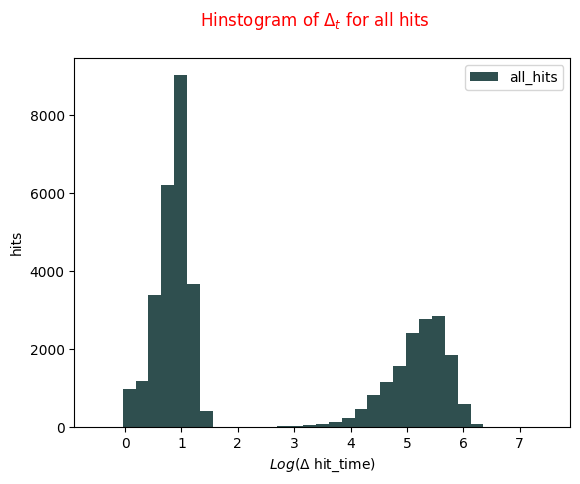

In [20]:
#Istogramma dei delta_t tra RECO.HIT consecutivi
delta_all= Delta_ht(all_ord_hits)
print(len(delta_all)) #dovrebbe essere 40729
delta_all_log= np.log10(delta_all)

n, bis, p = plt.hist(delta_all_log, bins=35, range=(-0.5, 7.5), color='darkslategray', label='all_hits')
plt.suptitle('Hinstogram of $\Delta_t$ for all hits', color='red')
plt.xlabel('$Log(\Delta$ hit_time)', fontsize=10)
plt.ylabel('hits', fontsize=10)
plt.legend(fontsize=10)

### Possibili estensioni del codice

#### Come stabilire la finestra temporale da applicare ai $\Delta t$ che permetta di raggruppare gli *Hit* dello stesso evento ma separi quelli apparteneti ad eventi differenti?

Innanzitutto, per decidere quali hits siano relativi ad uno stesso evento fisico di emissione di fotoni Cerenkov, dovrei stabilire un certo numero di hits come grado di confidenza che quel fenomeno sia significativo.

Poi potrei stabilire la finestra temporale in base al numero di hits che essa contiene: cioè selezionare tutti gli intervalli temporali che contengono un numero di hits maggiore di una certa quantità e fare una media pesata degli intervalli temporali sulla base del numero di hits che contengono.

#### Pensare a come dovrebbe essere strutturata una eventuale classe *Event* per descrivere l'evento fisico come osservato dal rivelatore (quindi basata suglli Hit).

Una classe **Events** che gestisce gli eventi di rilevati da un rivelatore dovrebbe avere come attributi:
- la classe **Presa dati** con le classi: 
    - **Hit* che registra la rilevazione di un fotone da parte di un sensore del rivelatore;
    - **Hits** registrati dal rivelatore per un certo tempo di acquisizione dati;
    - **Event** che registra, se è presente, un evento per quella presa dati;
- un *metodo* che consente di stabilire una finestra temporale per l'evento nel caso siano stati registrati un numero minimo di hits nella presa dati.

- quindi una *collezione di '*prese dati*'* con i relativi eventi, se registrati.